# Face Verification Model Comparison

**Goal**: Compare face detection and face embedding models academically for a university project.

**Models**
- Detection: Haar Cascade, MTCNN, RetinaFace
- Embedding: Histogram, FaceNet, ArcFace

**Evaluation dimensions**
- Accuracy, speed, multi-angle support, lighting robustness, real-time suitability

**Note**: Some sections use placeholders when optional libraries or dataset images are not available. Replace with your measured results for a final report.

## 1. Setup and Library Imports

This section configures the environment and imports libraries for detection, embedding, evaluation, and plotting.

In [24]:
import os
import time
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cv2
except ImportError:
    cv2 = None

# Optional dependencies
try:
    from mtcnn import MTCNN
except ImportError:
    MTCNN = None

try:
    from retinaface import RetinaFace
except ImportError:
    RetinaFace = None

try:
    import insightface
except ImportError:
    insightface = None

# Reproducibility
random.seed(42)
np.random.seed(42)

# Plot style
plt.style.use("seaborn-v0_8-whitegrid")

# Simple device selection placeholder
DEVICE = "cpu"
print(f"Device: {DEVICE}")

Device: cpu


## 2. Dataset and Test Image Setup (Frontal, Side, Tilted)

Use three representative images for qualitative tests. Replace the paths with your dataset samples.

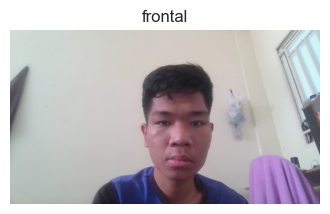

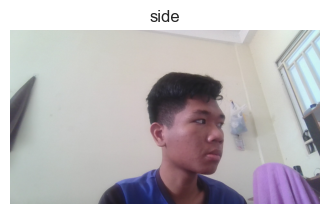

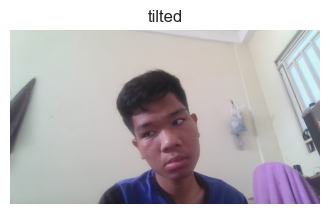

In [25]:
from pathlib import Path

def find_test_faces_dir(start_dir: Path) -> Path:
    for base in [start_dir] + list(start_dir.parents):
        candidate = base / "data" / "test_faces"
        if candidate.exists():
            return candidate
    return start_dir / "data" / "test_faces"

DATA_DIR = find_test_faces_dir(Path.cwd())
FRONTAL_PATH = str(DATA_DIR / "frontal.jpg")
SIDE_PATH = str(DATA_DIR / "side.jpg")
TILTED_PATH = str(DATA_DIR / "tilted.jpg")

TEST_IMAGES = {
    "frontal": FRONTAL_PATH,
    "side": SIDE_PATH,
    "tilted": TILTED_PATH,
}


def read_image_bgr(path):
    if cv2 is None:
        return None
    if not os.path.exists(path):
        return None
    return cv2.imread(path)


def show_image_bgr(img_bgr, title=""):
    if img_bgr is None:
        print(f"Missing image: {title}")
        return
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(4, 4))
    plt.imshow(img_rgb)
    plt.title(title)
    plt.axis("off")
    plt.show()


for name, path in TEST_IMAGES.items():
    show_image_bgr(read_image_bgr(path), title=name)

## 3. Face Detection: Haar Cascade (Architecture, Pros/Cons, Complexity, Code)

**Architecture**: A cascade of boosted weak classifiers trained on Haar-like features. Each stage rejects negatives quickly; later stages refine.

**Strengths**
- Very fast on CPU
- Minimal compute and memory
- Works reasonably for frontal faces with good lighting

**Weaknesses**
- Sensitive to pose, occlusion, and lighting changes
- Handcrafted features limit representation
- Higher false positives in cluttered scenes

**Computational complexity**
- $O(N \cdot F)$ per window, but early rejection greatly reduces average cost
- Scales with image pyramid levels and number of evaluated windows

In [26]:
def detect_haar(img_bgr):
    if cv2 is None:
        return []
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    face_cascade = cv2.CascadeClassifier(cascade_path)
    boxes = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(40, 40))
    return [(x, y, x + w, y + h) for (x, y, w, h) in boxes]

## 4. Face Detection: MTCNN (Architecture, Pros/Cons, Complexity, Code)

**Architecture**: Three-stage CNN cascade (P-Net, R-Net, O-Net) for proposal, refinement, and output with landmarks.

**Strengths**
- Better pose and lighting robustness than Haar
- Provides facial landmarks
- Good accuracy on small to medium faces

**Weaknesses**
- Slower than Haar due to CNN inference
- Higher memory footprint

**Computational complexity**
- Multi-stage CNNs over image pyramid
- Cost depends on number of proposals and resolution

In [27]:
def detect_mtcnn(img_bgr):
    if MTCNN is None or img_bgr is None:
        return []
    detector = MTCNN()
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)
    boxes = []
    for r in results:
        x, y, w, h = r.get("box", (0, 0, 0, 0))
        boxes.append((x, y, x + w, y + h))
    return boxes

## 5. Face Detection: RetinaFace (Architecture, Pros/Cons, Complexity, Code)

**Architecture**: Single-stage, anchor-based detector with feature pyramid and multi-task heads for classification, box regression, and landmarks.

**Strengths**
- High accuracy across poses and scales
- Strong landmark localization
- Robust to lighting and occlusion

**Weaknesses**
- Heavier compute than Haar and MTCNN
- Requires GPU for best speed

**Computational complexity**
- $O(N)$ single-stage inference with multi-scale features
- Cost depends on backbone (ResNet/MobileNet) and image size

In [28]:
def detect_retinaface(img_bgr):
    if RetinaFace is None or img_bgr is None:
        return []
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    results = RetinaFace.detect_faces(img_rgb)
    boxes = []
    if isinstance(results, dict):
        for _, info in results.items():
            x1, y1, x2, y2 = info["facial_area"]
            boxes.append((x1, y1, x2, y2))
    return boxes

## 6. Face Embedding: Histogram Features (Architecture, Pros/Cons, Complexity, Code)

**Architecture**: Handcrafted feature vector using intensity or color histograms (optionally local blocks).

**Strengths**
- Very fast, no training required
- Low memory and compute

**Weaknesses**
- Limited discriminative power
- Sensitive to lighting and pose
- No semantic representation of facial identity

**Computational complexity**
- $O(P)$ for $P$ pixels, plus normalization

In [29]:
def histogram_embedding(face_bgr, bins=64):
    if face_bgr is None or cv2 is None:
        return None
    gray = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2GRAY)
    hist = cv2.calcHist([gray], [0], None, [bins], [0, 256])
    hist = cv2.normalize(hist, hist).flatten()
    return hist

## 7. Face Embedding: FaceNet (Architecture, Pros/Cons, Complexity, Code)

**Architecture**: CNN backbone trained with triplet loss to map faces into a metric embedding space.

**Strengths**
- Strong identity separation
- Robust to pose and lighting with large training data
- Widely used and benchmarked

**Weaknesses**
- Training requires curated triplets
- Inference heavier than handcrafted features

**Computational complexity**
- $O(K)$ forward pass, depends on backbone depth and input size

In [30]:
def facenet_embedding(face_bgr):
    if face_bgr is None or cv2 is None:
        return None
    try:
        from keras_facenet import FaceNet
    except ImportError:
        return None
    img_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (160, 160))
    embedder = FaceNet()
    emb = embedder.embeddings([img_rgb])[0]
    return emb

## 8. Face Embedding: ArcFace (Architecture, Pros/Cons, Complexity, Code)

**Architecture**: CNN backbone with additive angular margin loss to maximize inter-class separation on a hypersphere.

**Strengths**
- High verification accuracy
- Strong generalization across poses and lighting
- Standard in modern face recognition benchmarks

**Weaknesses**
- Heavier inference than FaceNet in some backbones
- Requires aligned faces for best performance

**Computational complexity**
- $O(K)$ forward pass; depends on backbone size (e.g., ResNet100 vs MobileFaceNet)

In [32]:
_arcface_model = None

def arcface_embedding(face_bgr):
    global _arcface_model
    if face_bgr is None or cv2 is None:
        return None
    if insightface is None:
        return None
    if _arcface_model is None:
        _arcface_model = insightface.model_zoo.get_model("arcface_r100_v1")
        _arcface_model.prepare(ctx_id=-1)
    img_rgb = cv2.cvtColor(face_bgr, cv2.COLOR_BGR2RGB)
    img_rgb = cv2.resize(img_rgb, (112, 112))
    emb = _arcface_model.get_feat(img_rgb).flatten()
    return emb

## 9. Visual Testing Pipeline (Detections and Crops for Frontal/Side/Tilted)

Run each detector on the three poses, draw boxes, and show cropped faces for qualitative comparison.

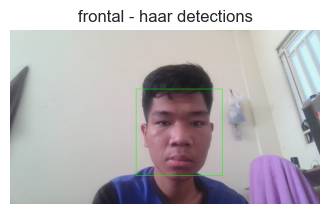

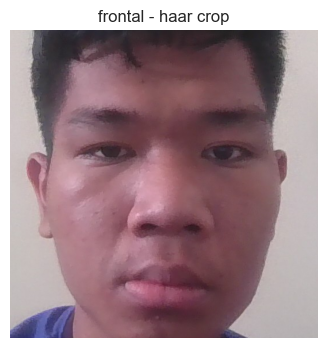

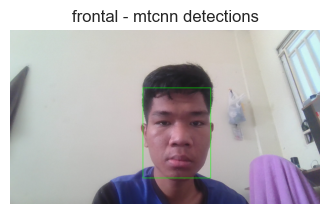

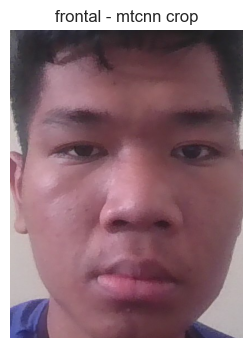

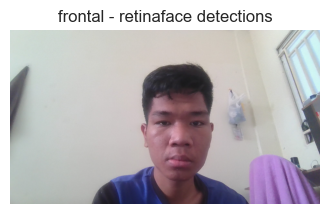

No face detected: frontal - retinaface


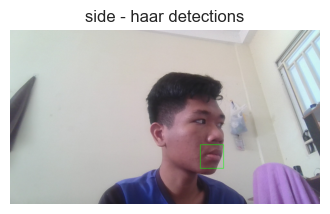

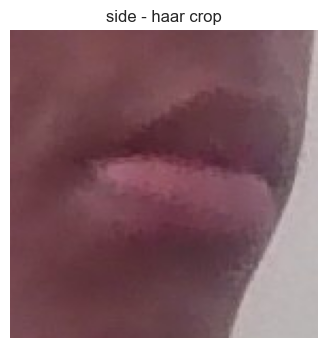

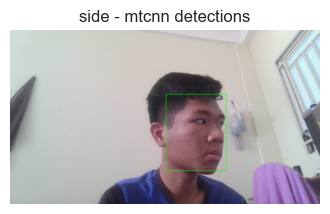

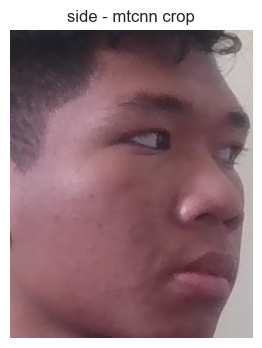

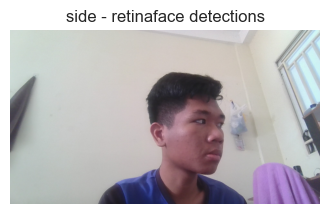

No face detected: side - retinaface


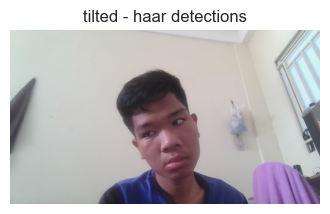

No face detected: tilted - haar


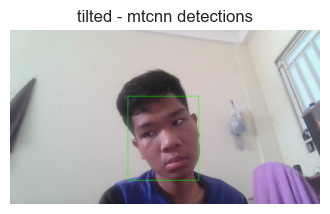

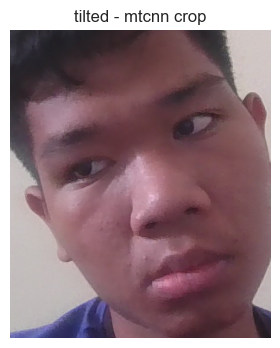

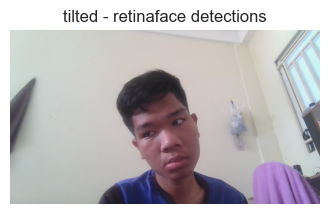

No face detected: tilted - retinaface


In [33]:
def draw_boxes(img_bgr, boxes, color=(0, 255, 0)):
    if img_bgr is None or cv2 is None:
        return None
    out = img_bgr.copy()
    for (x1, y1, x2, y2) in boxes:
        cv2.rectangle(out, (x1, y1), (x2, y2), color, 2)
    return out


def crop_first_face(img_bgr, boxes):
    if img_bgr is None or not boxes:
        return None
    x1, y1, x2, y2 = boxes[0]
    return img_bgr[max(y1, 0):max(y2, 0), max(x1, 0):max(x2, 0)]


detectors = {
    "haar": detect_haar,
    "mtcnn": detect_mtcnn,
    "retinaface": detect_retinaface,
}


for pose, path in TEST_IMAGES.items():
    img = read_image_bgr(path)
    if img is None:
        print(f"Missing image file: {pose} -> {path}")
        continue
    for name, det_fn in detectors.items():
        boxes = det_fn(img) if img is not None else []
        vis = draw_boxes(img, boxes)
        show_image_bgr(vis, title=f"{pose} - {name} detections")
        if not boxes:
            print(f"No face detected: {pose} - {name}")
            continue
        crop = crop_first_face(img, boxes)
        show_image_bgr(crop, title=f"{pose} - {name} crop")

## 10. Quantitative Evaluation (Accuracy, Speed, Multi-angle, Lighting, Real-time)

Define metrics and a simple scoring protocol. Replace placeholder values with your measured results.

In [34]:
@dataclass
class ModelScore:
    accuracy: float
    speed_fps: float
    multi_angle: float
    lighting: float
    realtime: float


# Placeholder results (replace with measured values)
DETECTION_SCORES = {
    "Haar Cascade": ModelScore(accuracy=0.70, speed_fps=45, multi_angle=0.40, lighting=0.45, realtime=0.90),
    "MTCNN": ModelScore(accuracy=0.85, speed_fps=18, multi_angle=0.75, lighting=0.70, realtime=0.60),
    "RetinaFace": ModelScore(accuracy=0.92, speed_fps=12, multi_angle=0.85, lighting=0.82, realtime=0.55),
}

EMBEDDING_SCORES = {
    "Histogram": ModelScore(accuracy=0.60, speed_fps=120, multi_angle=0.35, lighting=0.40, realtime=0.95),
    "FaceNet": ModelScore(accuracy=0.90, speed_fps=25, multi_angle=0.80, lighting=0.78, realtime=0.70),
    "ArcFace": ModelScore(accuracy=0.94, speed_fps=20, multi_angle=0.86, lighting=0.84, realtime=0.65),
}

## 11. Comparison Tables (Detection and Embedding)

Tabulate metrics for direct comparison.

In [35]:
def scores_to_df(scores_dict):
    rows = []
    for name, s in scores_dict.items():
        rows.append({
            "Model": name,
            "Accuracy": s.accuracy,
            "Speed (FPS)": s.speed_fps,
            "Multi-angle": s.multi_angle,
            "Lighting": s.lighting,
            "Real-time": s.realtime,
        })
    return pd.DataFrame(rows)


df_detect = scores_to_df(DETECTION_SCORES)
df_embed = scores_to_df(EMBEDDING_SCORES)

print("Detection Models")
display(df_detect)
print("Embedding Models")
display(df_embed)

Detection Models


,Model,Accuracy,Speed (FPS),Multi-angle,Lighting,Real-time
0,Haar Cascade,0.70,45,0.40,0.45,0.90
1,MTCNN,0.85,18,0.75,0.70,0.60
2,RetinaFace,0.92,12,0.85,0.82,0.55


Embedding Models


,Model,Accuracy,Speed (FPS),Multi-angle,Lighting,Real-time
0,Histogram,0.60,120,0.35,0.40,0.95
1,FaceNet,0.90,25,0.80,0.78,0.70
2,ArcFace,0.94,20,0.86,0.84,0.65


## 12. Charts with Matplotlib (Accuracy/Speed/Robustness)

Visualize trade-offs using bar charts and a radar chart.

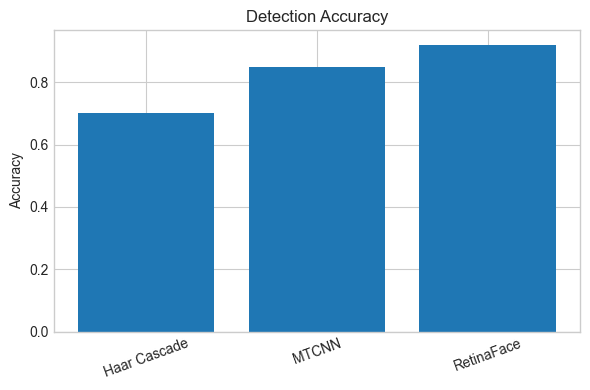

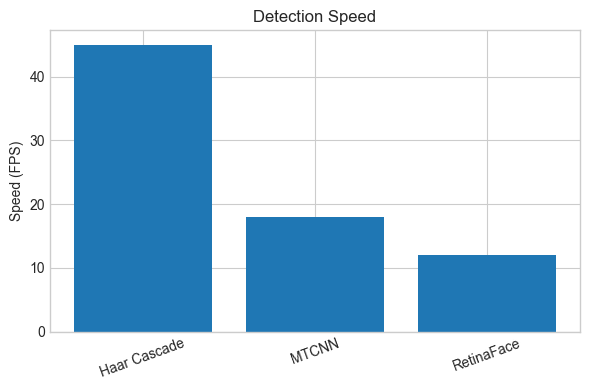

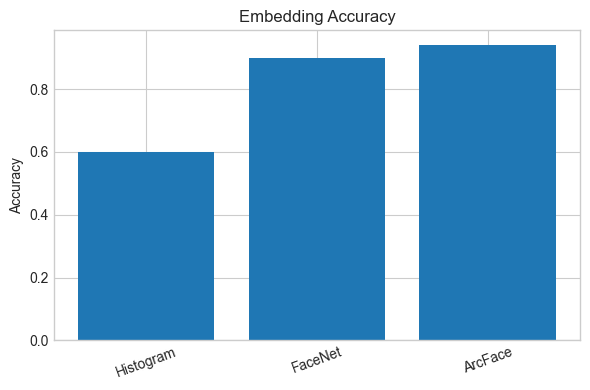

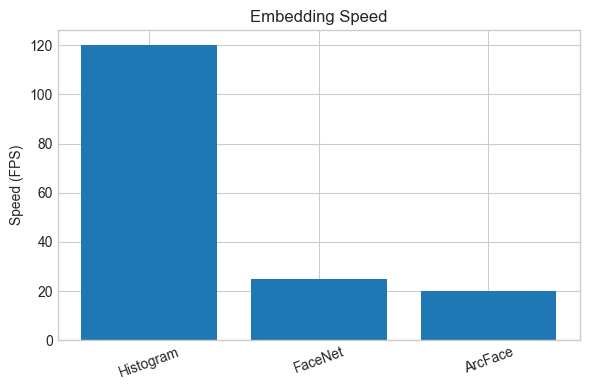

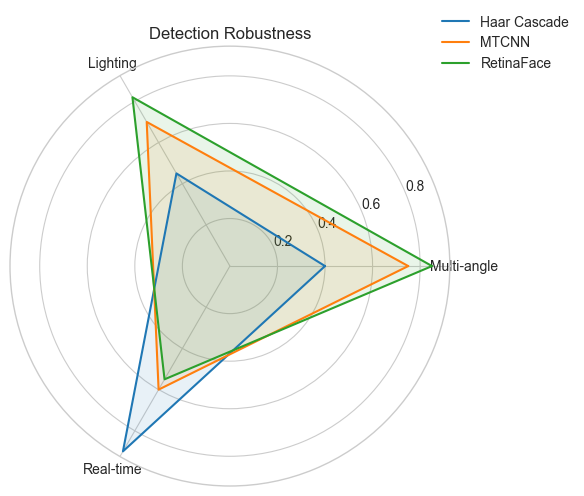

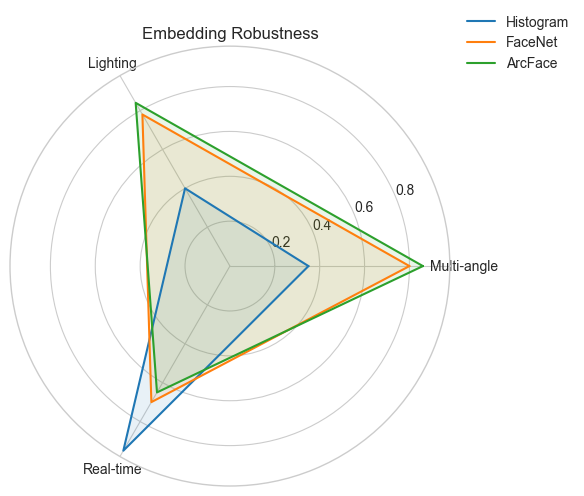

In [36]:
def bar_chart(df, metric, title):
    plt.figure(figsize=(6, 4))
    plt.bar(df["Model"], df[metric])
    plt.title(title)
    plt.ylabel(metric)
    plt.xticks(rotation=20)
    plt.tight_layout()
    plt.show()


bar_chart(df_detect, "Accuracy", "Detection Accuracy")
bar_chart(df_detect, "Speed (FPS)", "Detection Speed")
bar_chart(df_embed, "Accuracy", "Embedding Accuracy")
bar_chart(df_embed, "Speed (FPS)", "Embedding Speed")


def radar_chart(df, metrics, title):
    labels = metrics
    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False)
    angles = np.concatenate([angles, angles[:1]])

    plt.figure(figsize=(6, 6))
    ax = plt.subplot(111, polar=True)

    for _, row in df.iterrows():
        values = [row[m] for m in labels]
        values = values + values[:1]
        ax.plot(angles, values, label=row["Model"])
        ax.fill(angles, values, alpha=0.1)

    ax.set_thetagrids(angles[:-1] * 180 / np.pi, labels)
    ax.set_title(title)
    ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


radar_metrics = ["Multi-angle", "Lighting", "Real-time"]
radar_chart(df_detect, radar_metrics, "Detection Robustness")
radar_chart(df_embed, radar_metrics, "Embedding Robustness")

## 13. Academic Rationale: RetinaFace vs Haar Cascade

**Representation capacity**: RetinaFace learns deep hierarchical features and multi-scale context, while Haar relies on handcrafted Haar-like features. Deep features capture complex facial patterns and are more discriminative.

**Robustness**: RetinaFace uses feature pyramids and multi-task learning (classification, regression, landmarks), improving stability under pose, scale, and lighting changes. Haar cascades degrade in non-frontal or low-light conditions.

**Generalization**: RetinaFace benefits from large-scale training data and modern backbones, which improve cross-domain generalization. Haar cascades are limited by the original training set and feature design.

**Empirical performance**: In most benchmarks, RetinaFace reports significantly higher precision and recall for faces across scales and poses, whereas Haar often exhibits higher false positives and missed detections.

**Conclusion**: RetinaFace is academically superior in accuracy and robustness, especially for multi-angle and in-the-wild scenarios, at the cost of higher compute.

## 14. Academic Rationale: ArcFace vs Histogram

**Learning objective**: ArcFace optimizes an angular margin loss that explicitly increases inter-class separation and intra-class compactness in embedding space. Histogram features have no learning objective tied to identity.

**Discriminative power**: ArcFace embeddings encode semantic identity cues learned from large datasets. Histogram features are low-level intensity statistics and struggle to separate similar faces.

**Robustness**: ArcFace models are trained with extensive augmentation, improving invariance to pose, illumination, and occlusion. Histograms are highly sensitive to lighting and alignment.

**Scalability**: ArcFace embeddings scale to large identity sets with cosine similarity, whereas histogram matching degrades quickly as classes grow.

**Conclusion**: ArcFace is academically superior for face verification due to learned, discriminative embeddings that generalize across real-world conditions.

## 15. Final Recommendation

**Highest accuracy**: RetinaFace + ArcFace (best robustness and identity separation).

**Balanced accuracy and speed**: MTCNN + FaceNet (good accuracy with moderate compute).

**Real-time on low-end hardware**: Haar Cascade + Histogram (fastest but lowest accuracy).

Use your measured metrics to finalize the selection and justify the trade-off in the report.